In [1]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
from IPython.display import display

BASE = Path.cwd()

DOWNLOAD_DIRS = {
    "image_only": BASE / "wandb_downloads_image_only",
    "student_simulation": BASE / "wandb_downloads_student_simulation",
    "text_image_chart_only_action_text": BASE / "wandb_downloads_text_image_chart_only_action_text",
    "text_image_chart_only2": BASE / "wandb_downloads_text_image_chart_only2",
    "text_only": BASE / "wandb_downloads_text_only",
}

for name, path in DOWNLOAD_DIRS.items():
    print(f"{name:40s}", path, "EXISTS =", path.exists())

rows = []

target_files = [
    "summary.json",
    "trajectory.json",
    "interaction_log.json",
    "steps.json",
    "output.log",
]

for root_name, root_path in DOWNLOAD_DIRS.items():
    if not root_path.exists():
        continue

    for file_name in target_files:
        files = list(root_path.rglob(file_name))
        rows.append({
            "root": root_name,
            "file": file_name,
            "count": len(files),
        })

file_dist_df = pd.DataFrame(rows)

display(
    file_dist_df
    .pivot(index="root", columns="file", values="count")
    .fillna(0)
    .astype(int)
)

image_only                               \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_image_only EXISTS = True
student_simulation                       \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_student_simulation EXISTS = True
text_image_chart_only_action_text        \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_text_image_chart_only_action_text EXISTS = True
text_image_chart_only2                   \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_text_image_chart_only2 EXISTS = True
text_only                                \\wsl.localhost\Ubuntu\home\lly\projects\project\wandb_downloads_text_only EXISTS = True


file,interaction_log.json,output.log,steps.json,summary.json,trajectory.json
root,,,,,
image_only,360,36,360,360,360
student_simulation,40,4,40,40,40
text_image_chart_only2,360,36,360,360,360
text_image_chart_only_action_text,360,36,360,360,360
text_only,1259,126,1259,1259,1259


In [2]:
def safe_load_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print("Failed to load:", path, e)
        return None


def find_nearest_file(start_dir, filename, max_up=5):
    """
    从 summary.json 所在目录开始，向上找 output.log。
    适合 run_00/summary.json 这种结构。
    """
    start_dir = Path(start_dir)
    candidates = [start_dir] + list(start_dir.parents[:max_up])
    for d in candidates:
        p = d / filename
        if p.exists():
            return p
    return None


def read_text_if_exists(path):
    if path is None or not Path(path).exists():
        return ""
    try:
        return Path(path).read_text(encoding="utf-8", errors="replace")
    except Exception:
        return ""


def parse_output_log(log_text):
    """
    从 output.log 里解析 config/env/model/run_name。
    """
    out = {}

    patterns = {
        "config": r"Config:\s*(.+)",
        "env_config": r"Env override:\s*(.+)",
        "model_config": r"Model override:\s*(.+)",
        "run_name": r"Run name:\s*(.+)",
        "output_dir": r"Output dir:\s*(.+)",
        "task_mode": r"Task mode:\s*(.+)",
        "observation_mode": r"Observation mode:\s*(.+)",
        "target_variable": r"Target variable:\s*(.+)",
        "naming_mode": r"Naming mode:\s*(.+)",
        "action_mode": r"Action mode:\s*(.+)",
        "n_runs": r"N runs:\s*(\d+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, log_text)
        out[key] = m.group(1).strip() if m else None

    return out


FORMULAS = [
    "beers_wavelength",
    "beers",
    "concentration",
    "ohm",
    "resistors",
    "kinematics",
    "mass",
    "distance",
]

SETUPS = ["concrete", "abbrev", "abstract"]

KNOWN_MODELS = [
    "model_qwen25_vl_3b",
    "model_qwen25_vl_7b",
    "model_qwen25_3b",
    "model_qwen25_7b",
    "model_qwen35_4b",
    "model_qwen35_9b",
    "model_llama31_8b",
    "model_mistral_7b",
    "model_gemma3_4b",
]


def infer_formula(text):
    text = str(text).lower()
    for f in FORMULAS:
        if f in text:
            return f
    return None


def infer_setup(text):
    text = str(text).lower()
    for s in SETUPS:
        if re.search(rf"(^|[_\-/]){s}($|[_\-/\.])", text):
            return s
    return None


def infer_model(text):
    text = str(text)
    for m in KNOWN_MODELS:
        if m in text:
            return m

    # fallback: qwen25_vl_3b -> model_qwen25_vl_3b
    for m in KNOWN_MODELS:
        short = m.replace("model_", "")
        if short in text:
            return m

    # fallback regex
    m = re.search(r"(model_[A-Za-z0-9]+(?:_[A-Za-z0-9]+)*)", text)
    return m.group(1) if m else None


def infer_run_idx(text):
    text = str(text)
    patterns = [
        r"run[_\-](\d+)",
        r"run_(\d+)",
        r"-(\d+)(?:$|[:/])",
    ]
    for pat in patterns:
        m = re.search(pat, text)
        if m:
            return int(m.group(1))
    return None


def infer_modality(root_name, combined_text, config=None, run_name=None):
    """
    这里故意保留 modality_detail，避免把 chart-only 的不同版本误混在一起。
    """
    s = " ".join([
        str(root_name),
        str(combined_text),
        str(config),
        str(run_name),
    ]).lower()

    modality = None
    detail = None

    if "simulation" in s:
        modality = "Simulation-only"
        detail = "simulation"
    elif "text_only" in s or "config_text_only" in s:
        modality = "Text-only"
        detail = "text_only"
    elif "chart_only_no_action" in s or "image_only" in s:
        modality = "Chart-only"
        detail = "chart_only_no_action"
    elif "chart_only" in s:
        modality = "Chart-only"
        detail = "chart_only_action_text_or_unknown"
    elif "text_image" in s:
        modality = "Text+image"
        detail = "text_image"
    else:
        modality = "Unknown"
        detail = "unknown"

    return modality, detail


episode_rows = []

for root_name, root_path in DOWNLOAD_DIRS.items():
    if not root_path.exists():
        continue

    summary_paths = list(root_path.rglob("summary.json"))
    print(root_name, "summary files:", len(summary_paths))

    for summary_path in summary_paths:
        summary = safe_load_json(summary_path)
        if not isinstance(summary, dict):
            continue

        episode_dir = summary_path.parent
        output_log_path = find_nearest_file(episode_dir, "output.log")
        log_text = read_text_if_exists(output_log_path)
        log_info = parse_output_log(log_text)

        path_text = str(summary_path)
        combined_text = " ".join([
            root_name,
            path_text,
            log_text,
            str(log_info),
        ])

        evaluation = summary.get("evaluation", {}) or {}

        row = {
            "root": root_name,
            "episode_dir": str(episode_dir),
            "summary_path": str(summary_path),
            "trajectory_path": str(episode_dir / "trajectory.json"),
            "interaction_log_path": str(episode_dir / "interaction_log.json"),
            "steps_path": str(episode_dir / "steps.json"),
            "output_log_path": str(output_log_path) if output_log_path else None,
        }

        # top-level summary fields
        for k, v in summary.items():
            if k not in ["evaluation", "image_paths"]:
                row[k] = v

        # evaluation fields
        for k, v in evaluation.items():
            row[k] = v

        # log fields
        row.update(log_info)

        # inferred metadata
        row["formula"] = infer_formula(log_info.get("env_config") or combined_text)
        row["setup"] = infer_setup(log_info.get("env_config") or combined_text)
        row["model"] = infer_model(log_info.get("model_config") or combined_text)
        row["run_idx"] = infer_run_idx(combined_text)

        modality, modality_detail = infer_modality(
            root_name=root_name,
            combined_text=combined_text,
            config=log_info.get("config"),
            run_name=log_info.get("run_name"),
        )
        row["modality"] = modality
        row["modality_detail"] = modality_detail

        # useful derived indicators
        row["success_int"] = int(bool(row.get("success", False)))
        row["equation_correct_int"] = int(bool(row.get("equation_correct", False)))
        row["finish_called_int"] = int(bool(row.get("finish_called", False)))
        row["forced_finish_int"] = int(bool(row.get("forced_finish", False)))

        term = row.get("termination_reason")
        row["finish_wrong_int"] = int(term == "finish_wrong")
        row["parse_error_int"] = int((term == "parse_error") or (row.get("parse_error") not in [None, "", False]))

        episode_rows.append(row)


df = pd.DataFrame(episode_rows)

print("Total episodes:", len(df))
display(df.head())
display(df.columns.to_frame(index=False).rename(columns={0: "columns"}))

image_only summary files: 360
student_simulation summary files: 40
text_image_chart_only_action_text summary files: 360
text_image_chart_only2 summary files: 360
text_only summary files: 1259
Total episodes: 2379


,root,episode_dir,summary_path,trajectory_path,interaction_log_path,steps_path,output_log_path,final_equation,finish_reason,finish_reached,...,model,run_idx,modality,modality_detail,success_int,equation_correct_int,finish_called_int,forced_finish_int,finish_wrong_int,parse_error_int
0,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,d = d1 + d2 + d3,NaN,True,...,model_qwen25_vl_7b,None,Chart-only,chart_only_no_action,1,1,1,0,0,0
1,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,x = v + x0,NaN,True,...,model_qwen25_vl_7b,None,Chart-only,chart_only_no_action,0,0,1,0,1,0
2,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,m = rho + V,NaN,True,...,model_qwen25_vl_3b,None,Chart-only,chart_only_no_action,0,0,1,0,1,0
3,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,Rt = R2,NaN,True,...,model_qwen25_vl_3b,None,Chart-only,chart_only_no_action,0,0,1,0,1,0
4,image_only,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,\\wsl.localhost\Ubuntu\home\lly\projects\proje...,None,m = e^(rho * V),NaN,True,...,model_qwen25_vl_3b,None,Chart-only,chart_only_no_action,0,0,1,0,1,0


,columns
0,root
1,episode_dir
2,summary_path
3,trajectory_path
4,interaction_log_path
5,steps_path
6,output_log_path
7,final_equation
8,finish_reason
9,finish_reached


In [3]:
# 1. 每个 modality 多少条
display(
    df.groupby(["root", "modality", "modality_detail"])
      .size()
      .reset_index(name="n")
      .sort_values(["root", "modality", "modality_detail"])
)

# 2. 每个 formula × setup × modality 多少条
display(
    df.groupby(["modality", "modality_detail", "formula", "setup"])
      .size()
      .reset_index(name="n")
      .sort_values(["modality", "formula", "setup"])
)

# 3. 每个 model × modality 多少条
display(
    df.groupby(["modality", "modality_detail", "model"])
      .size()
      .reset_index(name="n")
      .sort_values(["modality", "model"])
)

# 4. termination reason 分布
display(
    df.groupby(["modality", "modality_detail", "termination_reason"])
      .size()
      .reset_index(name="n")
      .sort_values(["modality", "modality_detail", "n"], ascending=[True, True, False])
)

,root,modality,modality_detail,n
0,image_only,Chart-only,chart_only_no_action,360
1,student_simulation,Simulation-only,simulation,40
2,text_image_chart_only2,Chart-only,chart_only_no_action,360
3,text_image_chart_only_action_text,Chart-only,chart_only_action_text_or_unknown,360
4,text_only,Text-only,text_only,1259


,modality,modality_detail,formula,setup,n
0,Chart-only,chart_only_action_text_or_unknown,beers,abbrev,20
18,Chart-only,chart_only_no_action,beers,abbrev,40
1,Chart-only,chart_only_action_text_or_unknown,beers,abstract,20
19,Chart-only,chart_only_no_action,beers,abstract,40
2,Chart-only,chart_only_action_text_or_unknown,beers,concrete,20
20,Chart-only,chart_only_no_action,beers,concrete,40
3,Chart-only,chart_only_action_text_or_unknown,distance,abbrev,20
21,Chart-only,chart_only_no_action,distance,abbrev,40
4,Chart-only,chart_only_action_text_or_unknown,distance,abstract,20
22,Chart-only,chart_only_no_action,distance,abstract,40


,modality,modality_detail,model,n
0,Chart-only,chart_only_action_text_or_unknown,model_qwen25_vl_3b,180
2,Chart-only,chart_only_no_action,model_qwen25_vl_3b,360
1,Chart-only,chart_only_action_text_or_unknown,model_qwen25_vl_7b,180
3,Chart-only,chart_only_no_action,model_qwen25_vl_7b,360
4,Simulation-only,simulation,model_config,40
5,Text-only,text_only,model_gemma3_4b,180
6,Text-only,text_only,model_llama31_8b,180
7,Text-only,text_only,model_mistral_7b,179
8,Text-only,text_only,model_qwen25_3b,180
9,Text-only,text_only,model_qwen25_7b,180


,modality,modality_detail,termination_reason,n
1,Chart-only,chart_only_action_text_or_unknown,finish_wrong,219
0,Chart-only,chart_only_action_text_or_unknown,finish_success,139
2,Chart-only,chart_only_action_text_or_unknown,parse_error,2
4,Chart-only,chart_only_no_action,finish_wrong,461
3,Chart-only,chart_only_no_action,finish_success,250
5,Chart-only,chart_only_no_action,parse_error,9
6,Text-only,text_only,finish_success,796
7,Text-only,text_only,finish_wrong,463


In [4]:
ROOT_TO_MODALITY = {
    "text_only": "Text-only",
    "text_image_chart_only_action_text": "Text+image",
    "text_image_chart_only2": "Chart-only",
    "image_only": "Simulation-only",
    "student_simulation": "Student-simulation-later",
}

ROOT_TO_MODALITY_DETAIL = {
    "text_only": "text_only",
    "text_image_chart_only_action_text": "text_image",
    "text_image_chart_only2": "bar_chart_image_only",
    "image_only": "simulation_image_only",
    "student_simulation": "student_simulation_later",
}

df["modality_clean"] = df["root"].map(ROOT_TO_MODALITY)
df["modality_detail_clean"] = df["root"].map(ROOT_TO_MODALITY_DETAIL)

display(
    df.groupby(["root", "modality_clean", "modality_detail_clean"])
      .size()
      .reset_index(name="n")
      .sort_values("root")
)

,root,modality_clean,modality_detail_clean,n
0,image_only,Simulation-only,simulation_image_only,360
1,student_simulation,Student-simulation-later,student_simulation_later,40
2,text_image_chart_only2,Chart-only,bar_chart_image_only,360
3,text_image_chart_only_action_text,Text+image,text_image,360
4,text_only,Text-only,text_only,1259


In [5]:
df["finish_wrong_int"] = (
    (df["termination_reason"] == "finish_wrong") |
    (df["termination_reason"] == "parse_error") |
    (df["parse_error_int"] == 1)
).astype(int)

In [6]:
MODALITY_ROOTS = [
    "text_only",
    "text_image_chart_only_action_text",
    "text_image_chart_only2",
    "image_only",
]

main_df = df[df["root"].isin(MODALITY_ROOTS)].copy()

MODALITY_ORDER = [
    "Text-only",
    "Text+image",
    "Chart-only",
    "Simulation-only",
]

display(
    main_df.groupby(["modality_clean", "formula", "setup"])
           .size()
           .reset_index(name="n")
           .sort_values(["modality_clean", "formula", "setup"])
)

,modality_clean,formula,setup,n
0,Chart-only,beers,abbrev,20
1,Chart-only,beers,abstract,20
2,Chart-only,beers,concrete,20
3,Chart-only,distance,abbrev,20
4,Chart-only,distance,abstract,20
...,...,...,...,...
67,Text-only,ohm,abstract,69
68,Text-only,ohm,concrete,70
69,Text-only,resistors,abbrev,70
70,Text-only,resistors,abstract,70


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

,modality_clean,success_rate,finish_wrong_rate,n
3,Text-only,0.632248,0.385226,1259
2,Text+image,0.386111,0.613889,360
0,Chart-only,0.344444,0.655556,360
1,Simulation-only,0.350000,0.650000,360


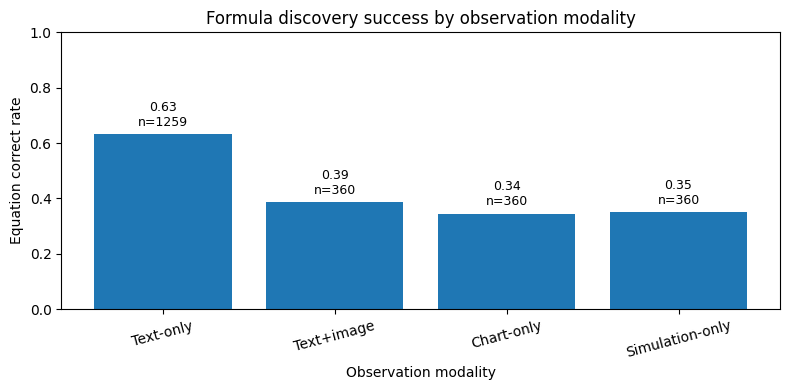

In [ ]:
success_df = (
    main_df
    .groupby("modality_clean", as_index=False)
    .agg(
        success_rate=("equation_correct_int", "mean"),
        finish_wrong_rate=("finish_wrong_int", "mean"),
        n=("equation_correct_int", "size"),
    )
)

success_df["modality_clean"] = pd.Categorical(
    success_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)success_df = (
    main_df
    .groupby("modality_clean", as_index=False)
    .agg(
        success_rate=("equation_correct_int", "mean"),
        finish_wrong_rate=("finish_wrong_int", "mean"),
        n=("equation_correct_int", "size"),
    )
)

success_df["modality_clean"] = pd.Categorical(
    success_df["modality_clean"],
    categories=MODALITY_ORDER,
    ordered=True,
)

success_df = success_df.sort_values("modality_clean")

display(success_df)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(success_df["modality_clean"], success_df["success_rate"])

ax.set_ylim(0, 1)
ax.set_ylabel("Equation correct rate")
ax.set_xlabel("Observation modality")
ax.set_title("Formula discovery success by observation modality")

for i, row in enumerate(success_df.itertuples()):
    ax.text(
        i,
        row.success_rate + 0.02,
        f"{row.success_rate:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
ax.bar(success_df["modality_clean"], success_df["success_rate"])

ax.set_ylim(0, 1)
ax.set_ylabel("Equation correct rate")
ax.set_xlabel("Observation modality")
ax.set_title("Formula discovery success by observation modality")

for i, row in enumerate(success_df.itertuples()):
    ax.text(
        i,
        row.success_rate + 0.02,
        f"{row.success_rate:.2f}\nn={row.n}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()